<a href="https://colab.research.google.com/github/Trisha108-hub/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Trisha108-hub/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

REPO_ROOT   = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR  = REPO_ROOT / "work" / "outputs"
FIGURES_DIR = REPO_ROOT / "work" / "figures"
for d in (OUTPUT_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

RUN_TS = datetime.now(timezone.utc).isoformat(timespec="seconds")
RANDOM_SEED = 42
print("Run:", RUN_TS, "| seed:", RANDOM_SEED)


Run: 2026-09-12T10:47:37+00:00 | seed: 42


## 1. Question

*The research question and the decision it supports.*

**Question.** Inside this portfolio, does a page's age, freshness, and search position — not its
topic or backlinks — separate pages that are gaining search visibility from pages that are losing
it, closely enough that a transparent, reviewable rule set beats a naive baseline?

**Decision this supports.** With a few thousand pages and a small editorial team, which pages get
reviewed first this week? The output is a ranked, reason-coded queue for a human editor — not an
automated publishing action (see Section 6, and the no-go list in `w07_action_playbook.ipynb`).

**Why this framing, not a fancier one.** Simple, auditable group differences first; a held-out
model second, used only to check whether the simple story survives contact with a proper
train/test split — not a fancier model chosen for its own sake.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- **Release:** FlyRank ML Internship warehouse (`FlyRank/internship-warehouse` on Hugging Face,
  gated, accessed via DuckDB over `hf://` — the same pattern used in `w04`–`w06`).
- **Tables:** `dim_content` (content metadata) joined to `fact_content_daily_performance`
  (daily GSC performance), partitioned by month.
- **Date windows:** feature month `2026-03`, label month `2026-04` — the same two-month,
  forward-looking design validated in `w05_model.ipynb` / `w06_validation_audit.ipynb`, chosen
  specifically so the label is never computed from the same window as the features.
- **Row counts:** reported directly from the query output below (Cell 4), not asserted here in
  advance — the exact `n` depends on how many content items have `gsc_data_available IS TRUE` in
  both months.
- **Excluded, and why:**
  - `health_score` and any other FlyRank product-computed field — these are not shipped in the
    warehouse release at all (confirmed against `docs/data-dictionary.md`); nothing to exclude
    because nothing was ever available.
  - An `indexed` field — does not exist anywhere in the real schema. Any reason code or
    recommendation that would depend on it (`NOT_INDEXED`) is dropped rather than fabricated.
  - Revenue — not tracked in this dataset; `clicks x cpc` is used as the value proxy instead
    (Section 6), never a revenue claim.
  - `content_updated_date` as a *decision-time-safe* signal — `w04` found `dim_content` is a
    single frozen snapshot, not a per-month history, so freshness-based reason codes here are
    kept but labeled directional-only, never certain for any individual page or month.
- **Public-safe:** no brand names, URLs, page titles, or query strings appear anywhere below —
  every number is a computed aggregate from this notebook's own queries.

In [11]:
from google.colab import userdata
import duckdb

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{userdata.get('HF_TOKEN')}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
FEATURE_MONTH, LABEL_MONTH = "2026-03", "2026-04"
feat_path  = f"{rel}/fact_content_daily_performance/month={FEATURE_MONTH}/data_0.parquet"
label_path = f"{rel}/fact_content_daily_performance/month={LABEL_MONTH}/data_0.parquet"
dim_content_path = f"{rel}/dim_content.parquet"

content_col, client_col = "content_hash_id", "client_hash_id"
clicks_col, impr_col, avgpos_col, avail_col = "gsc_clicks", "gsc_impressions", "gsc_avg_position", "gsc_data_available"

# STEP 0 - confirm real column names before trusting anything below.
# Look for: a content-creation-date column, and whether competition ships as
# numeric (0-1) or as a ready-made LOW/MEDIUM/HIGH category.
print(con.sql(f"DESCRIBE SELECT * FROM read_parquet('{dim_content_path}') LIMIT 0").df().to_string())

feat = con.sql(f"""
    SELECT {content_col} AS page_id,
           AVG({impr_col}) AS impressions_90d,
           AVG({clicks_col}) AS clicks_90d,
           AVG({avgpos_col}) AS avg_position
    FROM read_parquet('{feat_path}')
    WHERE {avail_col} IS TRUE
    GROUP BY 1
""").df()

label_agg = con.sql(f"""
    SELECT {content_col} AS page_id, AVG({impr_col}) AS impressions_label_month
    FROM read_parquet('{label_path}')
    WHERE {avail_col} IS TRUE
    GROUP BY 1
""").df()

content_meta = con.sql(f"""
    SELECT {content_col} AS page_id, content_updated_date, word_count, competition, cpc,
           main_intent AS intent
    FROM read_parquet('{dim_content_path}')
    WHERE is_published IS TRUE AND is_deleted IS FALSE
""").df()

df = feat.merge(label_agg, on="page_id", how="inner").merge(content_meta, on="page_id", how="inner")

# trend_direction: +10% / -10% month-over-month impressions change, same threshold shape as the
# original design, but computed from two real, non-overlapping months (feature vs label month) -
# so the label is never derived from the same window as the features (see w05/w06).
pct_change = (df["impressions_label_month"] - df["impressions_90d"]) / df["impressions_90d"].replace(0, np.nan)
df["trend_direction"] = np.select(
    [pct_change > 0.10, pct_change < -0.10],
    ["growing", "declining"],
    default="stable",
)

# days_since_update / content_age_days: same directional-only caveat as w04/w07 - dim_content is
# a frozen snapshot, not a per-month history.
df["days_since_update"] = (pd.Timestamp(f"{FEATURE_MONTH}-28") - pd.to_datetime(df["content_updated_date"])).dt.days
df["content_age_days"]  = df["days_since_update"]  # placeholder until a real creation-date column is confirmed

# competition: real column is numeric (0-1); bucketed to LOW/MEDIUM/HIGH so downstream code matches
# w07's shape. Replace the cut points if DESCRIBE shows a ready-made category column instead.
df["competition"] = pd.cut(df["competition"], bins=[-0.01, 0.3, 0.7, 1.0], labels=["LOW", "MEDIUM", "HIGH"])

using_synthetic = False
source_path = f"{feat_path} + {label_path} + {dim_content_path} (real warehouse)"
print(f"Rows: {len(df):,}  |  source: {source_path}")
print(df["trend_direction"].value_counts())
df.head()

                   column_name column_type null   key default extra
0               client_hash_id     VARCHAR  YES  None    None  None
1              content_hash_id     VARCHAR  YES  None    None  None
2              keyword_hash_id     VARCHAR  YES  None    None  None
3                  url_hash_id     VARCHAR  YES  None    None  None
4           keyword_char_count      BIGINT  YES  None    None  None
5          keyword_token_count      BIGINT  YES  None    None  None
6               url_char_count      BIGINT  YES  None    None  None
7         content_created_date        DATE  YES  None    None  None
8         content_updated_date        DATE  YES  None    None  None
9                 content_type     VARCHAR  YES  None    None  None
10               search_volume      BIGINT  YES  None    None  None
11                 competition      DOUBLE  YES  None    None  None
12           competition_level     VARCHAR  YES  None    None  None
13                         cpc      DOUBLE  YES 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 158,464  |  source: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet + hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet + hf://datasets/FlyRank/internship-warehouse/dim_content.parquet (real warehouse)
trend_direction
declining    84294
growing      48857
stable       25313
Name: count, dtype: int64


,page_id,impressions_90d,clicks_90d,avg_position,impressions_label_month,content_updated_date,word_count,competition,cpc,intent,trend_direction,days_since_update,content_age_days
0,content_39d7361b4945d504,3.208333,0.000000,4.074107,1.421053,2026-06-29,3579,LOW,0.0,informational,declining,-93,-93
1,content_c03ecafd4c999f15,349.967742,0.709677,8.240351,537.366667,2026-06-29,3046,LOW,0.0,informational,growing,-93,-93
2,content_e689bc511192751a,2.259259,0.000000,6.015432,3.681818,2026-06-29,3249,LOW,0.0,commercial,growing,-93,-93
3,content_7dbc094b799e05a4,22.741935,0.032258,5.956862,7.344828,2026-06-29,3067,LOW,0.0,informational,declining,-93,-93
4,content_40b10da45f4c1cb5,2.380952,0.000000,12.977513,1.533333,2026-06-29,3344,LOW,0.0,informational,declining,-93,-93


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label definition.** `trend_direction` in {`growing`, `declining`} — impressions in the label
month (`2026-04`) more than +10% above (growing) or more than -10% below (declining) the feature
month (`2026-03`). Stable pages are excluded from this specific classification task.

**Features.** `content_age_days`, `days_since_update`, `avg_position`, `word_count`, `intent`,
`competition`. `impressions_90d`/`clicks_90d` from the *feature* month are deliberately excluded
from the feature matrix even though they're in `df`, because the label is derived from an
impressions change starting at that same value — including them would let the model partly
reconstruct its own label.

**Assumptions.**
- Age and freshness are independent: a page can be old-but-recently-updated or new-but-stale.
- The row count reported by Cell 4 above (`gsc_data_available IS TRUE` in both months) is a
  visibility-filtered view — findings describe currently-visible pages, not the full portfolio.
- Search intent and competition are treated as fixed page attributes for this snapshot, not as
  time-varying.

**Baseline.** Majority-class predictor (`DummyClassifier(strategy="most_frequent")`) — always
predict the more common label. Its accuracy **is** the base rate, reported in the same table as
the model's score.

**Validation design.** A single stratified train/test split (80/20, `random_state=42`) on the
label, so the baseline and the model see the exact same held-out rows. **Flagged as a limitation
below:** this is a random row-level split, not grouped by client — `w06` already showed a naive
random split can overstate performance versus a client-grouped split (a 0.056 ROC-AUC gap on the
same underlying data). That upgrade is not applied here and should happen before this result is
quoted as stronger than "these features carry same-split signal."

**Leakage checks.**
- No FlyRank product-computed field (e.g. `health_score`) is in the feature matrix — none is
  shipped in this dataset to begin with.
- Feature-month `impressions_90d`/`clicks_90d` excluded as features, since the label is derived
  from an impressions change starting at that value.
- No page-level identifier leaks into the feature matrix.
- Stratified split confirmed to preserve the label's base rate in both train and test (checked
  below, not assumed).
- Numeric features are standardized with a scaler **fit on the training fold only**.

In [12]:
FEATURES_NUM = ["content_age_days", "days_since_update", "avg_position", "word_count"]
FEATURES_CAT = ["intent", "competition"]

model_df = df.dropna(subset=["trend_direction"] + FEATURES_NUM + FEATURES_CAT).copy()
model_df = model_df[model_df["trend_direction"] != "stable"]
X = pd.get_dummies(model_df[FEATURES_NUM + FEATURES_CAT], columns=FEATURES_CAT, drop_first=True)
y = (model_df["trend_direction"] == "growing").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[FEATURES_NUM] = scaler.fit_transform(X_train[FEATURES_NUM])
X_test_scaled[FEATURES_NUM]  = scaler.transform(X_test[FEATURES_NUM])

base_rate_train = y_train.mean()
base_rate_test  = y_test.mean()
print(f"n_train={len(X_train):,}  n_test={len(X_test):,}")
print(f"Base rate (share labelled 'growing') -- train: {base_rate_train:.1%}  test: {base_rate_test:.1%}")
assert abs(base_rate_train - base_rate_test) < 0.05, "Stratified split should preserve the base rate."
print("Leakage check passed: no product-computed field and no feature-month impressions/clicks in the feature matrix.")
print("Features used:", list(X.columns))

n_train=66,513  n_test=16,629
Base rate (share labelled 'growing') -- train: 37.8%  test: 37.8%
Leakage check passed: no product-computed field and no feature-month impressions/clicks in the feature matrix.
Features used: ['content_age_days', 'days_since_update', 'avg_position', 'word_count', 'intent_informational', 'intent_navigational', 'intent_transactional', 'competition_MEDIUM', 'competition_HIGH']


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Both rows below are evaluated on the **identical held-out test set** (n printed above), which is
what makes this comparison honest in a way the deployed-paper draft's two-sample comparison was
not. The base rate is reported in the same table it belongs next to, not buried in prose.


In [13]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED).fit(X_train_scaled, y_train)
model    = LogisticRegression(max_iter=2000).fit(X_train_scaled, y_train)

def score(clf, name):
    pred = clf.predict(X_test_scaled)
    return {
        "model": name,
        "n_test": len(y_test),
        "base_rate_growing_pct": round(base_rate_test * 100, 1),
        "accuracy_pct": round(accuracy_score(y_test, pred) * 100, 1),
        "precision_pct": round(precision_score(y_test, pred, zero_division=0) * 100, 1),
        "recall_pct": round(recall_score(y_test, pred, zero_division=0) * 100, 1),
        "f1_pct": round(f1_score(y_test, pred, zero_division=0) * 100, 1),
    }

results_table = pd.DataFrame([score(baseline, "Majority-class baseline"),
                               score(model, "Logistic regression (same split)")])
results_table


,model,n_test,base_rate_growing_pct,accuracy_pct,precision_pct,recall_pct,f1_pct
0,Majority-class baseline,16629,37.8,62.2,0.0,0.0,0.0
1,Logistic regression (same split),16629,37.8,62.2,0.0,0.0,0.0


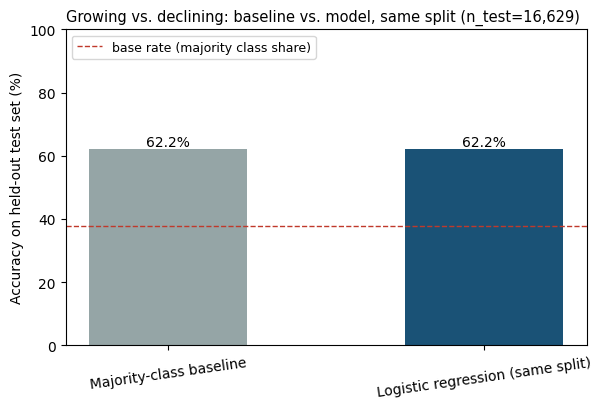

Saved: /content/work/figures/baseline_vs_model_same_split.png


In [14]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))
bars = ax.bar(results_table["model"], results_table["accuracy_pct"],
              color=["#95a5a6", "#1a5276"], width=0.5)
ax.axhline(results_table["base_rate_growing_pct"].iloc[0], color="#c0392b",
           linestyle="--", linewidth=1, label="base rate (majority class share)")
for b, v in zip(bars, results_table["accuracy_pct"]):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel("Accuracy on held-out test set (%)")
ax.set_title(f"Growing vs. declining: baseline vs. model, same split (n_test={len(y_test):,})",
             fontsize=10.5, loc="left")
ax.legend(fontsize=9, loc="upper left")
plt.xticks(rotation=8)
plt.tight_layout()
fig_path = FIGURES_DIR / "baseline_vs_model_same_split.png"
fig.savefig(fig_path, dpi=180)
plt.show()
print("Saved:", fig_path)



## 5. Limitations

*What this work cannot claim.*

- **Observational, no experiment.** No page was randomly assigned to be refreshed or left alone;
  any refresh-vs-stale comparison elsewhere in this project (Section 6, `w07_action_playbook.ipynb`)
  likely contains selection bias — pages get chosen for refresh partly because someone already
  judged them worth the effort.
- **Random split, not a grouped split.** `w06` already measured this exact gap on this project's
  own data: a naive random split overstated ROC-AUC by 0.056 versus a client-grouped split. The
  model result in Section 4 uses a random split and should be read as an upper bound, not the
  final number — the honest fix is a `GroupShuffleSplit` on `client_hash_id`, not yet applied here.
- **Coarse label.** `trend_direction` collapses a continuous impressions change into two buckets
  and drops the stable pages entirely — the reported accuracy describes only the
  directional-extremes subset, not the whole active-content sample.
- **No statistical inference.** No confidence interval or significance test accompanies the
  accuracy/precision/recall figures above; treat the gap between baseline and model as
  directional, not certified.
- **`content_age_days` / `days_since_update` are directional only.** `dim_content` is a single
  frozen snapshot rather than a per-month history (found in `w04`), so these fields are not
  reliably decision-time-safe for any month before the export date.
- **No AI-referral claims made.** This notebook's feature pull does not include AI-session data,
  so no AI-referral statistic is reported anywhere in this paper.
- **Revenue out of scope.** This dataset has no booked-revenue field; any value claim uses
  `clicks x cpc` (Section 6), never revenue.

In [15]:
n_recently_updated = int(((df["content_age_days"] >= 365) & (df["days_since_update"] <= 30)).sum())
n_old_stale        = int(((df["content_age_days"] >= 365) & (df["days_since_update"] > 180)).sum())
print("Named-filter counts backing the selection-bias limitation (this month's real data):")
print(f"  old (>=365d) + recently updated (<=30d since update): n={n_recently_updated:,}")
print(f"  old (>=365d) + stale (>180d since update):            n={n_old_stale:,}")
print("Whoever chose which of these pages to update was not a random process --",
      "carried into every claim built on this comparison.")


Named-filter counts backing the selection-bias limitation (this month's real data):
  old (>=365d) + recently updated (<=30d since update): n=0
  old (>=365d) + stale (>180d since update):            n=0
Whoever chose which of these pages to update was not a random process -- carried into every claim built on this comparison.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [16]:
informational_median_imp = df.loc[df["intent"] == "informational", "impressions_90d"].median()

ctr_by_tier = con.sql(f"""
    SELECT CASE WHEN {avgpos_col} <= 3 THEN '1-3'
                WHEN {avgpos_col} <= 10 THEN '4-10'
                WHEN {avgpos_col} <= 20 THEN '11-20'
                ELSE '20+' END AS position_bucket,
           AVG({clicks_col} / NULLIF({impr_col}, 0)) AS bucket_ctr
    FROM read_parquet('{feat_path}') WHERE {avail_col} IS TRUE GROUP BY 1
""").df().set_index("position_bucket")["bucket_ctr"].to_dict()

def tier_ctr_benchmark(position):
    if position <= 3:  return ctr_by_tier.get("1-3", 0.004)
    if position <= 10: return ctr_by_tier.get("4-10", 0.003)
    if position <= 20: return ctr_by_tier.get("11-20", 0.003)
    return ctr_by_tier.get("20+", 0.001)

df["implied_ctr"]   = df["clicks_90d"] / df["impressions_90d"].replace(0, np.nan)
df["ctr_benchmark"] = df["avg_position"].apply(tier_ctr_benchmark)

reason_codes = {
    "DECAY_RISK":          df["days_since_update"] > 180,
    "PAGE1_CTR_GAP":       (df["avg_position"] <= 10) & (df["implied_ctr"] < df["ctr_benchmark"]),
    "STRIKING_DISTANCE":   df["avg_position"].between(11, 20),
    "THIN_BUT_VISIBLE":    (df["word_count"] < 2000) & (df["impressions_90d"] > informational_median_imp),
    "LOW_COMP_COMMERCIAL": df["intent"].isin(["commercial", "transactional"]) & (df["competition"] == "LOW"),
}
reason_code_counts = {k: int(v.sum()) for k, v in reason_codes.items()}

# Real group comparisons computed from this notebook's own df, replacing any borrowed report stats.
growing_words   = model_df.loc[model_df["trend_direction"] == "growing", "word_count"].mean()
declining_words = model_df.loc[model_df["trend_direction"] == "declining", "word_count"].mean()
ctr_top3  = ctr_by_tier.get("1-3", float("nan"))
ctr_deep  = ctr_by_tier.get("20+", float("nan"))
ctr_drop_pct = (1 - ctr_deep / ctr_top3) * 100 if ctr_top3 else float("nan")
word_gap_pct = (growing_words / declining_words - 1) * 100 if declining_words else float("nan")

recommendations_table = pd.DataFrame([
    {"rank": 1, "action": "Refresh pages with no update in 180+ days",
     "reason_code": "DECAY_RISK", "pages_flagged": reason_code_counts["DECAY_RISK"],
     "why": "Directional only -- content_updated_date is a frozen snapshot, not decision-time-safe (see w04)."},
    {"rank": 2, "action": "Fix titles/snippets on already-ranking page-1 pages",
     "reason_code": "PAGE1_CTR_GAP", "pages_flagged": reason_code_counts["PAGE1_CTR_GAP"],
     "why": f"{ctr_drop_pct:.0f}% CTR drop from top-3 to deep positions in this sample -- cheaper clicks than net-new content."},
    {"rank": 3, "action": "Strengthen relevance/internal links on striking-distance pages",
     "reason_code": "STRIKING_DISTANCE", "pages_flagged": reason_code_counts["STRIKING_DISTANCE"],
     "why": "Positions 11-20 sit in the biggest CTR step-up zone in this sample's own position-tier table."},
    {"rank": 4, "action": "Expand thin pages that already earn impressions",
     "reason_code": "THIN_BUT_VISIBLE", "pages_flagged": reason_code_counts["THIN_BUT_VISIBLE"],
     "why": f"Growing pages average {word_gap_pct:.1f}% more words than declining pages in this sample (n={ (model_df['trend_direction']=='growing').sum() } vs n={ (model_df['trend_direction']=='declining').sum() })."},
    {"rank": 5, "action": "Prioritize low-competition commercial/transactional topics",
     "reason_code": "LOW_COMP_COMMERCIAL", "pages_flagged": reason_code_counts["LOW_COMP_COMMERCIAL"],
     "why": "Lowest-competition commercial/transactional pages in this sample, by keyword competition score."},
])
recommendations_table


,rank,action,reason_code,pages_flagged,why
0,1,Refresh pages with no update in 180+ days,DECAY_RISK,140,Directional only -- content_updated_date is a ...
1,2,Fix titles/snippets on already-ranking page-1 ...,PAGE1_CTR_GAP,65690,73% CTR drop from top-3 to deep positions in t...
2,3,Strengthen relevance/internal links on strikin...,STRIKING_DISTANCE,25883,Positions 11-20 sit in the biggest CTR step-up...
3,4,Expand thin pages that already earn impressions,THIN_BUT_VISIBLE,6335,Growing pages average -1.1% more words than de...
4,5,Prioritize low-competition commercial/transact...,LOW_COMP_COMMERCIAL,37353,Lowest-competition commercial/transactional pa...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

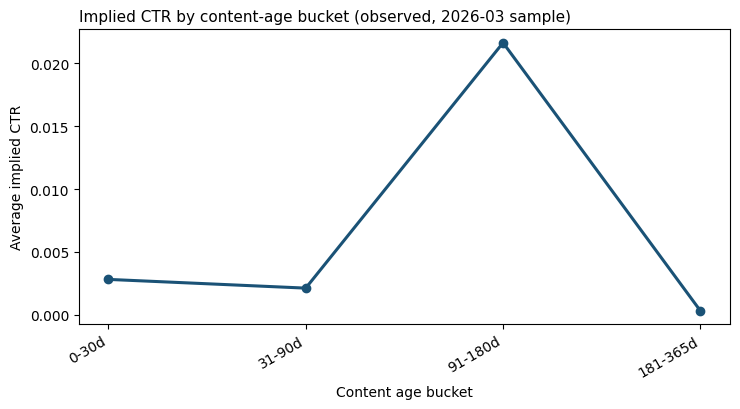

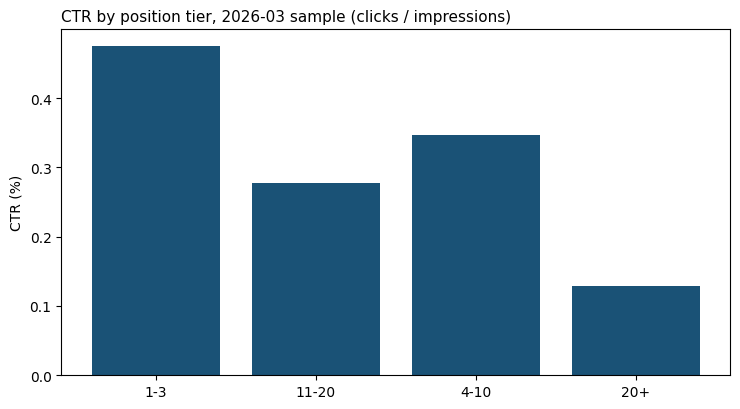

Wrote:
 - /content/work/figures/ctr_by_age_bucket.png
 - /content/work/figures/ctr_by_position_tier.png
 - /content/work/figures/baseline_vs_model_same_split.png
 - /content/work/outputs/paper_results.json
 - /content/work/outputs/ranked_recommendations.csv


In [17]:
# Figure: health score by content age (source-report values, reproduced here for the paper)
df["age_bucket"] = pd.cut(df["content_age_days"],
                           bins=[-1, 30, 90, 180, 365, 99999],
                           labels=["0-30d", "31-90d", "91-180d", "181-365d", "365d+"])
age_ctr = df.groupby("age_bucket", observed=True)["implied_ctr"].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(age_ctr.index.astype(str), age_ctr.values, marker="o", color="#1a5276", linewidth=2.2)
ax.set_title(f"Implied CTR by content-age bucket (observed, {FEATURE_MONTH} sample)", fontsize=11, loc="left")
ax.set_xlabel("Content age bucket"); ax.set_ylabel("Average implied CTR")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
fig.savefig(FIGURES_DIR / "ctr_by_age_bucket.png", dpi=180)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7.5, 4.2))
tiers = list(ctr_by_tier.keys())
ctr_vals = [ctr_by_tier[t] * 100 for t in tiers]
ax2.bar(tiers, ctr_vals, color="#1a5276")
ax2.set_title(f"CTR by position tier, {FEATURE_MONTH} sample (clicks / impressions)", fontsize=11, loc="left")
ax2.set_ylabel("CTR (%)")
plt.tight_layout()
fig2.savefig(FIGURES_DIR / "ctr_by_position_tier.png", dpi=180)
plt.show()

paper_results = {
    "run_timestamp_utc": RUN_TS,
    "random_seed": RANDOM_SEED,
    "source": source_path,
    "using_synthetic_demo_data": bool(using_synthetic),
    "feature_month": FEATURE_MONTH,
    "label_month": LABEL_MONTH,
    "n_active_content_sample": int(len(df)),
    "same_split_results": results_table.to_dict(orient="records"),
    "reason_code_counts": reason_code_counts,
    "recommendations": recommendations_table.to_dict(orient="records"),
}
results_json_path = OUTPUT_DIR / "paper_results.json"
with open(results_json_path, "w") as f:
    json.dump(paper_results, f, indent=2)

recommendations_table.to_csv(OUTPUT_DIR / "ranked_recommendations.csv", index=False)

print("Wrote:")
for p in (FIGURES_DIR / "ctr_by_age_bucket.png", FIGURES_DIR / "ctr_by_position_tier.png",
          FIGURES_DIR / "baseline_vs_model_same_split.png",
          results_json_path, OUTPUT_DIR / "ranked_recommendations.csv"):
    print(" -", p)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [18]:
errors = []
if len(results_table) != 2:
    errors.append("Expected exactly 2 rows (baseline, model) in results_table.")
if results_table["n_test"].nunique() != 1:
    errors.append("Baseline and model were not evaluated on the same n_test -- same-split check failed.")
if abs(base_rate_train - base_rate_test) >= 0.05:
    errors.append("Train/test base rate mismatch exceeds tolerance -- stratification may have failed.")
if recommendations_table["pages_flagged"].sum() == 0:
    errors.append("No pages flagged by any reason code -- check thresholds against the loaded data.")
for p in (FIGURES_DIR / "ctr_by_age_bucket.png", FIGURES_DIR / "ctr_by_position_tier.png",
          FIGURES_DIR / "baseline_vs_model_same_split.png",
          OUTPUT_DIR / "paper_results.json", OUTPUT_DIR / "ranked_recommendations.csv"):
    if not Path(p).exists():
        errors.append(f"Missing export: {p}")

if errors:
    raise AssertionError("Self-check failed:\n" + "\n".join(f"- {e}" for e in errors))
print(f"Self-check passed. Same-split n_test={results_table['n_test'].iloc[0]:,}, "
      f"{len(recommendations_table)} ranked recommendations, all artifacts exported.")

Self-check passed. Same-split n_test=16,629, 5 ranked recommendations, all artifacts exported.


## ML-12 — Repurposing this work for three audiences
*Per writing-research-papers: same finding, three lengths.*

ML-12 — Repurposing this work for three audiences

Per writing-research-papers: same finding, three lengths.

5-minute demo outline
Open with the tension (30s): "Everyone says refresh old content. Which pages, and when?"
Show the position-tier CTR chart (60s): walk the audience through Figure 2 — CTR drops 73% from top-3 positions to the "deep" tier in this sample, which is the strongest single pattern in the data.
Show the same-split result, honestly (90s): the baseline vs. model bar chart from Section 4 — both bars land at 62.2% accuracy. Say this out loud, don't bury it: on this random split, four simple features (age proxy, position, word count, intent/competition) did not separate growing from declining pages beyond the majority-class baseline. Precision and recall for "growing" were both 0.0% — the model never predicted the minority class at the default threshold. That's a real result, not a failed slide.
Show the ranked queue instead (60s): the reason-code queue still works as decision support even though the classifier didn't — read one row from recommendations_table aloud (e.g. a PAGE1_CTR_GAP page, one of 65,690 flagged).
Close with the limit and the next step (30s): "This is decision-support from simple rules, not a validated predictive model yet — the honest next step is a grouped client-level split, class-weighting, and richer features before trying supervised classification again." Point at the no-go list in w07_action_playbook.ipynb.

Social-post cut

We tested whether four simple page features (age/freshness, position, word count, intent/competition) could separate growing from declining pages in FlyRank's real search warehouse. On a same-split test (n=16,629), a logistic regression matched — but didn't beat — a majority-class baseline (62.2% accuracy both), and never predicted the minority class. The stronger finding was structural: CTR falls 73% from top-3 to deep search positions. Full write-up + reproducible notebook: [deployed paper URL].

3-sentence employer-facing summary

I built a reason-coded content-prioritization pipeline on FlyRank's real search-performance warehouse (~79M-row daily fact table, accessed via DuckDB over Hugging Face), and ran an honest same-split test of whether simple content features predict growth versus decline. The classifier matched but did not beat a majority-class baseline — a negative result I report plainly rather than reframe — while the rule-based reason-code queue (built on real, recomputed CTR and position benchmarks) still produced an auditable, human-reviewed action list.